In [135]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [136]:
X1_obs = np.load("f1initial_inputs.npy")
y1_obs = np.load("f1initial_outputs.npy")
print("file shapes F1 ", X1_obs.shape, y1_obs.shape)

X2_obs = np.load("f2initial_inputs.npy")
y2_obs = np.load("f2initial_outputs.npy")
print("file shapes F2 ", X2_obs.shape, y2_obs.shape)

X3_obs = np.load("f3initial_inputs.npy")
y3_obs = np.load("f3initial_outputs.npy")
print("file shapes F3 ", X3_obs.shape, y3_obs.shape)

X4_obs = np.load("f4initial_inputs.npy")
y4_obs = np.load("f4initial_outputs.npy")
print("file shapes F4 ", X4_obs.shape, y4_obs.shape)

X5_obs = np.load("f5initial_inputs.npy")
y5_obs = np.load("f5initial_outputs.npy")
print("file shapes F5 ", X5_obs.shape, y5_obs.shape)

X6_obs = np.load("f6initial_inputs.npy")
y6_obs = np.load("f6initial_outputs.npy")
print("file shapes F6 ", X6_obs.shape, y6_obs.shape)

X7_obs = np.load("f7initial_inputs.npy")
y7_obs = np.load("f7initial_outputs.npy")
print("file shapes F7 ", X7_obs.shape, y7_obs.shape)

X8_obs = np.load("f8initial_inputs.npy")
y8_obs = np.load("f8initial_outputs.npy")
print("file shapes F8 ", X8_obs.shape, y8_obs.shape)


file shapes F1  (12, 2) (12,)
file shapes F2  (12, 2) (12,)
file shapes F3  (17, 3) (17,)
file shapes F4  (32, 4) (32,)
file shapes F5  (22, 4) (22,)
file shapes F6  (22, 5) (22,)
file shapes F7  (32, 6) (32,)
file shapes F8  (42, 8) (42,)


In [137]:
def expected_improvement(X, gp, y_best, xi=0.01, minimize=True):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    if minimize:
        improvement = y_best - mu - xi
    else:
        improvement = mu - y_best - xi

    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

In [138]:
def propose_next_point(X_obs, y_obs, bounds, n_candidates=5000):
    
    ei_tol=1e-6
    
    """
    Black-box Bayesian optimization (minimization)

    X_obs: (N, D)
    y_obs: (N,)
    bounds: list of (low, high), length D
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidates
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])

    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )

    # Best (minimum) observed value
    y_best = np.min(y_obs)

    # Expected Improvement for minimization
    ei = expected_improvement(
        X_candidates,
        gp,
        y_best,
        minimize=True
    )
    ei = np.asarray(ei).ravel()

    # "Good" points: expected improvement toward smaller values
    good_mask = ei > ei_tol

    if np.any(good_mask):
        idx = np.argmax(ei[good_mask])
        x_next = X_candidates[good_mask][idx]
    else:
        # Exploration fallback
        x_next = X_candidates[np.argmax(ei)]


    return x_next

In [139]:
def propose_next_point_ucb(
    X_obs,
    y_obs,
    bounds,
    n_candidates=5000,
    kappa=3.0
):
    """
    Bayesian Optimization proposal using UCB (minimization-safe)
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidate points
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )

    # Predict GP mean and std
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    # LCB = mean - kappa * std
    lcb = mu - kappa * sigma

    # Pick the candidate with lowest LCB
    idx = np.argmin(lcb)
    x_next = X_candidates[idx]

    return x_next


In [140]:
def propose_next_point_ts(
    X_obs,
    y_obs,
    bounds,
    n_candidates=5000,
    kappa=3.0
):
    """
    Bayesian Optimization proposal using Thompson sampling
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidate points
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )
    
    # Get posterior mean and std for all candidates
    mu, sigma = gp.predict(X_candidates, return_std=True)
        
    # Draw ONE sample from the posterior for each candidate
    samples = mu + sigma * np.random.randn(n_candidates)
    
    # Return the candidate with the highest sampled value
    best_idx = np.argmax(samples)
    return X_candidates[best_idx]


In [141]:
def propose_next_point_UCB_or_TS(
    X_obs,
    y_obs,
    bounds,
    n_candidates=5000,
    kappa=3.0,
    alpha=1.0  # controls exploration bias in TS
):
    """
    Exploration-aware Thompson Sampling:
    - TS is biased toward high-uncertainty regions
    - UCB is used for comparison
    - Returns next point, TS sigma, and UCB sigma
    """
    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    # Fit GP
    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidates
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    X_candidates = np.random.uniform(low=lows, high=highs, size=(n_candidates, dim))

    # GP posterior
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    # --- Exploration-aware TS ---
    ts_scores = mu + sigma * np.random.randn(n_candidates) + alpha * sigma
    best_idx_ts = np.argmax(ts_scores)
    x_ts_next = X_candidates[best_idx_ts]
    sigma_ts = sigma[best_idx_ts]

    # --- UCB for comparison ---
    lcb = mu - kappa * sigma
    best_idx_ucb = np.argmin(lcb)
    x_ucb_next = X_candidates[best_idx_ucb]
    sigma_ucb = sigma[best_idx_ucb]

    # --- Pick point with higher uncertainty ---
    if sigma_ucb >= sigma_ts:
        print("UCB selected more exploratory point", "TS sigma:", sigma_ts, "UCB sigma:", sigma_ucb)
        x_next = x_ucb_next
    else:
        print("TS selected more exploratory point", "TS sigma:", sigma_ts, "UCB sigma:", sigma_ucb)
        x_next = x_ts_next

    return x_next
    # , sigma_ts, sigma_ucb    


In [145]:
# F1 - new query point

bounds1 = [(0.0, 1.0), (0.0, 1.0)]

x_UCB_TS_next = propose_next_point_UCB_or_TS(X1_obs, y1_obs, bounds1)
print("F1 Next query point UCB or TS :", np.round(x_UCB_TS_next,6) )

# x_EI_next1 = propose_next_point(X1_obs, y1_obs, bounds1)
# x_UCB_next1 = propose_next_point_ucb(X1_obs, y1_obs, bounds1)

# x_EI_next = None
# x_ei_points = []

# x_UCB_next = None
# x_ucb_points = []
# x_TS_next = None
# x_ts_points = []
# tol = 0.2
# range_vec = np.array([b[1] - b[0] for b in bounds1])

# for i in range(20):
#     x_UCB_next = propose_next_point_ucb(X1_obs, y1_obs, bounds1)
#     x_TS_next = propose_next_point_ts(X1_obs, y1_obs, bounds1)
#     scaled_dist = np.linalg.norm((x_TS_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     x_ucb_points.append(x_UCB_next.ravel()[0])
#     x_ts_points.append(x_TS_next.ravel()[0])
#     if agree == True :
#         print("F1 agreed next query point:",i, agree, np.round(x_TS_next,6),np.round(x_UCB_next,6))
#         break
#     # else :
#         # print("F1 unequal next query point:",i, agree, np.round(x_TS_next,6),np.round(x_UCB_next,6))
    


UCB selected more exploratory point TS sigma: 0.000996663063489224 UCB sigma: 0.000996663063489224
F1 Next query point UCB or TS : [0.677598 0.526745]


In [146]:
# print(x_ucb_points.shape)

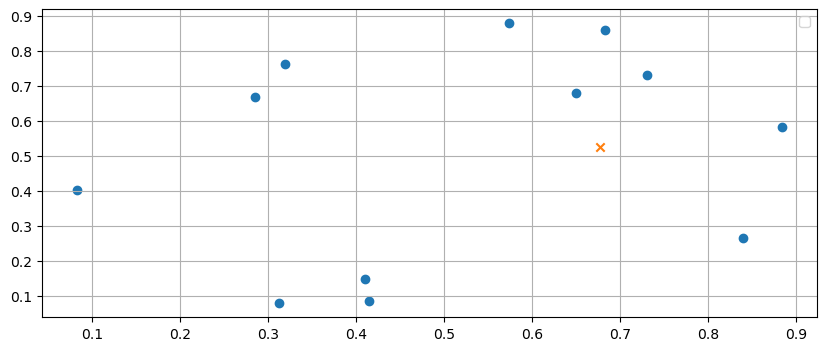

In [147]:
# F1 graph - to check 

x_points = X1_obs
# x_next_point = np.array([0.901543,0.538506])
y_points = y1_obs

plt.figure(figsize=(10,4))
plt.scatter(x_points[:,0],x_points[:,1],marker="o")
plt.scatter(x_UCB_TS_next[0],x_UCB_TS_next[1], marker = "x")
# plt.plot(x_EI_next)
plt.legend()
plt.grid(True)
plt.show()


In [148]:
# F2 - new query point

bounds2 = [(0.0, 1.0), (0.0, 1.0)]


x_UCB_TS_next2 = propose_next_point_UCB_or_TS(X2_obs, y2_obs, bounds2)
print("F2 Next query point UCB or TS :", np.round(x_UCB_TS_next2,6) )

# x_EI_next2 = propose_next_point(X2_obs, y2_obs, bounds2)
# x_UCB_next2 = propose_next_point_ucb(X2_obs, y2_obs, bounds2)
# print("F2 Next query point EI and UCB :", x_EI_next2,x_UCB_next2)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.2
# range_vec = np.array([b[1] - b[0] for b in bounds2])

# for i in range(10):
#     x_EI_next = propose_next_point(X2_obs, y2_obs, bounds2)
#     x_UCB_next = propose_next_point_ucb(X2_obs, y2_obs, bounds2)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F2 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        

UCB selected more exploratory point TS sigma: 0.22153444216953053 UCB sigma: 0.22153444216953053
F2 Next query point UCB or TS : [0.947193 0.541641]


In [155]:
bounds3 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0)]


x_UCB_TS_next3 = propose_next_point_UCB_or_TS(X3_obs, y3_obs, bounds3)
print("F3 Next query point UCB or TS :", np.round(x_UCB_TS_next3,6) )

# # x_EI_next3 = propose_next_point(X3_obs, y3_obs, bounds3)
# # x_UCB_next3 = propose_next_point_ucb(X3_obs, y3_obs, bounds3)

# # print("F3 Next query point EI and UCB :", x_EI_next3,x_UCB_next3)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.2
# range_vec = np.array([b[1] - b[0] for b in bounds3])

# for i in range(10):
#     x_EI_next = propose_next_point(X3_obs, y3_obs, bounds3)
#     x_UCB_next = propose_next_point_ucb(X3_obs, y3_obs, bounds3)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F3 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        


UCB selected more exploratory point TS sigma: 0.08030766627174894 UCB sigma: 0.08030766627174894
F3 Next query point UCB or TS : [0.467499 0.452954 0.575318]


In [150]:
bounds4 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]


x_UCB_TS_next4 = propose_next_point_UCB_or_TS(X4_obs, y4_obs, bounds4)
print("F4 Next query point UCB or TS :", np.round(x_UCB_TS_next4,6) )

# # x_EI_next4 = propose_next_point(X4_obs, y4_obs, bounds4)
# # x_UCB_next4 = propose_next_point_ucb(X4_obs, y4_obs, bounds4)

# # print("F4 Next query point EI and UCB :", x_EI_next4,x_UCB_next4)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.25
# range_vec = np.array([b[1] - b[0] for b in bounds4])

# for i in range(40):
#     x_EI_next = propose_next_point(X4_obs, y4_obs, bounds4)
#     x_UCB_next = propose_next_point_ucb(X4_obs, y4_obs, bounds4)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F4 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    



UCB selected more exploratory point TS sigma: 6.8028928680146645 UCB sigma: 6.8028928680146645
F4 Next query point UCB or TS : [0.916234 0.405014 0.449955 0.072506]


In [151]:
bounds5 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

x_UCB_TS_next5 = propose_next_point_UCB_or_TS(X5_obs, y5_obs, bounds5)
print("F5 Next query point UCB or TS :", np.round(x_UCB_TS_next5,6) )

# # x_EI_next5 = propose_next_point(X5_obs, y5_obs, bounds5)
# # x_UCB_next5 = propose_next_point_ucb(X5_obs, y5_obs, bounds5)

# # print("F5 Next query point EI and UCB :", x_EI_next5,x_UCB_next5)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.2
# range_vec = np.array([b[1] - b[0] for b in bounds5])

# for i in range(40):
#     x_EI_next = propose_next_point(X5_obs, y5_obs, bounds5)
#     x_UCB_next = propose_next_point_ucb(X5_obs, y5_obs, bounds5)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F5 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        



UCB selected more exploratory point TS sigma: 236.0059353226553 UCB sigma: 236.0059353226553
F5 Next query point UCB or TS : [0.478893 0.010438 0.627304 0.050096]


In [152]:
bounds6 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

x_UCB_TS_next6 = propose_next_point_UCB_or_TS(X6_obs, y6_obs, bounds6)
print("F6 Next query point UCB or TS :", np.round(x_UCB_TS_next6,6) )

# x_EI_next6 = propose_next_point(X6_obs, y6_obs, bounds6)
# x_UCB_next6 = propose_next_point_ucb(X6_obs, y6_obs, bounds6)

# print("F6 Next query point EI and UCB :", x_EI_next6,x_UCB_next6)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.3
# range_vec = np.array([b[1] - b[0] for b in bounds6])

# for i in range(40):
#     x_EI_next = propose_next_point(X6_obs, y6_obs, bounds6)
#     x_UCB_next = propose_next_point_ucb(X6_obs, y6_obs, bounds6)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F6 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    



UCB selected more exploratory point TS sigma: 0.44378698862679444 UCB sigma: 0.44378698862679444
F6 Next query point UCB or TS : [0.177508 0.387041 0.342993 0.664788 0.059064]


In [153]:
bounds7 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

x_UCB_TS_next7 = propose_next_point_UCB_or_TS(X7_obs, y7_obs, bounds7)
print("F7 Next query point UCB or TS :", np.round(x_UCB_TS_next7,6) )

# x_EI_next7 = propose_next_point(X7_obs, y7_obs, bounds7)
# x_UCB_next7 = propose_next_point_ucb(X7_obs, y7_obs, bounds7)

# # print("F7 Next query point EI and UCB :", x_EI_next7,x_UCB_next7)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.5
# range_vec = np.array([b[1] - b[0] for b in bounds7])

# for i in range(40):
#     x_EI_next = propose_next_point(X7_obs, y7_obs, bounds7)
#     x_UCB_next = propose_next_point_ucb(X7_obs, y7_obs, bounds7)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F7 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    

UCB selected more exploratory point TS sigma: 0.30369676383156646 UCB sigma: 0.30369676383156646
F7 Next query point UCB or TS : [0.649933 0.291298 0.222102 0.129627 0.265598 0.014656]


In [157]:
bounds8 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0), (0.0,1.0), (0.0,1.0), (0.0,1.0),(0.0,1.0)]

x_UCB_TS_next8 = propose_next_point_UCB_or_TS(X8_obs, y8_obs, bounds8)
print("F8 Next query point UCB or TS :", np.round(x_UCB_TS_next8,6) )

# # x_EI_next8 = propose_next_point(X8_obs, y8_obs, bounds8)
# # x_UCB_next8 = propose_next_point_ucb(X8_obs, y8_obs, bounds8)

# # print("F8 Next query point EI and UCB :", x_EI_next8,x_UCB_next8)
# x_EI_next = None
# x_UCB_next = None
# x_ei_points = []
# x_ucb_points = []
# tol = 0.3
# range_vec = np.array([b[1] - b[0] for b in bounds8])

# for i in range(40):
#     x_EI_next = propose_next_point(X8_obs, y8_obs, bounds8)
#     x_UCB_next = propose_next_point_ucb(X8_obs, y8_obs, bounds8)
#     x_ei_points.append(x_EI_next.ravel()[0])
#     x_ucb_points.append(x_UCB_next.ravel()[0])
    
#     scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
#     agree = scaled_dist < tol
#     if agree == True :
#         print("F8 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    


UCB selected more exploratory point TS sigma: 0.17818153856228983 UCB sigma: 0.188556783839327
F8 Next query point UCB or TS : [0.948953 0.533039 0.999577 0.671638 0.433809 0.820448 0.907676 0.601768]


In [84]:
# plt.hist(x_ei_points, bins=20, alpha=0.5, label='EI')
# plt.hist(x_ucb_points, bins=20, alpha=0.5, label='UCB')
# plt.xlabel('x value')
# plt.ylabel('Frequency')
# plt.title('Distribution of suggested x values')
# plt.legend()
# plt.show()

In [77]:
print(X1_obs)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.284551   0.668744  ]]


In [78]:
print(y1_obs)

[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -1.88477605e-056]
